# Qwen3Guard-Stream: потоковый baseline

Ноутбук запускает один токенный проход Qwen3Guard для каждой трассы, сохраняет его и затем воспроизводит шесть режимов буферизации с двумя политиками безопасности. Логика эксперимента импортируется из Python-пакета; полные чувствительные запросы и ответы не выводятся.

## 1. Конфигурация

`smoke` выбирает 5 безопасных и 5 опасных трасс. `full` использует все 500. Для локальной проверки без NVIDIA можно заменить `cuda` на `cpu`, но показатели времени после этого нельзя напрямую сравнивать с запуском на видеокарте.

In [1]:
import platform
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch

from streamguard_bench.experiments import (
    load_boundary_dataset,
    load_experiment_run,
    run_experiment,
    select_profile_traces,
)
from streamguard_bench.guards import Qwen3GuardStreamAdapter
from streamguard_bench.metrics import compute_streaming_metrics

PROFILE = "smoke"  # "smoke" или "full"
RUN_MODEL = False  # False читает готовые файлы, True запускает Qwen3Guard
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
RESUME = True
SEED = 42
DATASET_REVISION = "c36ddf315be89916c64fd6eb3b5a00ea6d505d1a"
MODEL_REVISION = "419364a715de9840d47b1457982f64ff37f90ed4"

MODES = ["token", "chunk_8", "chunk_16", "chunk_32", "sentence", "full_buffered"]
POLICIES = ["strict", "conservative"]
ROOT = Path.cwd() if (Path.cwd() / "pyproject.toml").exists() else Path.cwd().parent
OUTPUT_DIR = ROOT / "data/interim/qwen3guard_baseline"

## 2. Окружение

Эти сведения нужны для воспроизводимости задержки. Версии модели и токенизатора дополнительно сохраняются рядом с результатами.

In [2]:
environment = {
    "profile": PROFILE,
    "device": DEVICE,
    "python": platform.python_version(),
    "platform": platform.platform(),
    "output_dir": str(OUTPUT_DIR),
}
pd.Series(environment, name="value")

profile                                                   smoke
device                                                      cpu
python                                                  3.11.14
platform                           macOS-26.5.1-arm64-arm-64bit
output_dir    /Users/admin/Desktop/SelfImprove/Science/Strea...
Name: value, dtype: str

## 3. Загрузка и выбор трасс

Показываются только идентификаторы, итоговые метки и категории. Текст запросов и ответов остаётся внутри объекта данных.

In [3]:
if RUN_MODEL:
    dataset = load_boundary_dataset(
        revision=DATASET_REVISION,
        cache_dir=ROOT / "data/cache/huggingface",
    )
    selected = select_profile_traces(dataset, PROFILE, seed=SEED)
    print(f"Выбрано трасс: {len(selected)}")
    display(selected[["trace_id", "source_split", "label", "harm_categories"]])
else:
    dataset = None
    print("Датасет не загружается: используем сохранённый результат.")

Датасет не загружается: используем сохранённый результат.


## 4. Загрузка Qwen3Guard

Загружается модель `Qwen/Qwen3Guard-Stream-0.6B`. Она не обучается: используются опубликованные веса.

In [4]:
if RUN_MODEL:
    guard = Qwen3GuardStreamAdapter(
        "Qwen/Qwen3Guard-Stream-0.6B",
        revision=MODEL_REVISION,
        tokenizer_revision=MODEL_REVISION,
        device=DEVICE,
    )
    print({
        "model": guard.model_id,
        "model_revision": guard.model_revision,
        "tokenizer_revision": guard.tokenizer_revision,
        "device": guard.device,
    })
else:
    guard = None
    print("Модель не загружается: используем сохранённый результат.")

Модель не загружается: используем сохранённый результат.


## 5. Запуск или продолжение

После каждой трассы токенные решения сохраняются в `data/interim`. При повторном запуске с `RESUME = True` завершённые трассы не вычисляются заново.

In [5]:
if RUN_MODEL:
    run = run_experiment(
        dataset=dataset,
        guard=guard,
        profile=PROFILE,
        modes=MODES,
        policies=POLICIES,
        output_dir=OUTPUT_DIR,
        resume=RESUME,
        seed=SEED,
        dataset_revision=DATASET_REVISION,
    )
else:
    run = load_experiment_run(OUTPUT_DIR, profile=PROFILE)
print(f"Результаты: {run.output_dir}")
print(f"Трасс: {len(run.selected_trace_ids)}; токенных решений: {len(run.token_decisions)}")

Результаты: /Users/admin/Desktop/SelfImprove/Science/Streaming Guardrails/data/interim/qwen3guard_baseline/smoke
Трасс: 10; токенных решений: 1076


## 6. Проверка полноты

Для `smoke` ожидается 120 строк, для `full` — 6000. Ошибка одной трассы представлена во всех 12 комбинациях, поэтому её нельзя незаметно принять за безопасный результат.

In [6]:
expected_traces = 10 if PROFILE == "smoke" else 500
expected_rows = expected_traces * len(MODES) * len(POLICIES)
assert len(run.results) == expected_rows, (len(run.results), expected_rows)
assert run.results[["trace_id", "mode", "policy"]].duplicated().sum() == 0
print(f"Строк: {len(run.results)} из {expected_rows}; ошибок трасс: {len(run.errors)}")
display(run.errors)

Строк: 120 из 120; ошибок трасс: 0


,trace_id,error_type,error


## 7. Базовые метрики

> **Важно:** результаты по 10 трассам проверяют работоспособность конвейера. Они не являются статистической оценкой качества Qwen3Guard. Исследовательские выводы можно делать только после профиля `full`.

In [7]:
metrics = compute_streaming_metrics(
    run.results,
    group_by=["mode", "policy"],
)
display(metrics)

,mode,policy,traces,failed_traces,safe_traces,unsafe_traces,blocked_traces,false_positives,false_negatives,false_positive_rate,...,released_tokens_mean,leakage_min_mean,leakage_max_mean,signal_token_mean,intervention_token_mean,detection_delay_min_mean,detection_delay_max_mean,checks_mean,guard_time_ms_median,guard_time_ms_p95
0,chunk_16,conservative,10,0,5,5,7,2,0,0.4,...,54.7,0.0,0.0,45.428571,57.142857,-9.8,16.0,4.3,6486.383437,57269.433087
1,chunk_16,strict,10,0,5,5,6,1,0,0.2,...,58.1,0.0,0.0,14.500000,26.666667,-9.8,16.0,4.5,6486.383437,61649.484564
2,chunk_32,conservative,10,0,5,5,7,2,0,0.4,...,54.7,0.0,0.0,45.428571,71.428571,3.8,29.6,2.6,8056.788354,61140.258264
3,chunk_32,strict,10,0,5,5,6,1,0,0.2,...,58.1,0.0,0.0,14.500000,40.666667,3.8,29.6,2.7,8056.788354,61649.484564
4,chunk_8,conservative,10,0,5,5,7,2,0,0.4,...,55.5,0.0,0.0,45.428571,50.285714,-17.8,8.0,7.8,5038.831895,54744.839724
5,chunk_8,strict,10,0,5,5,6,1,0,0.2,...,58.9,0.0,0.0,14.500000,20.000000,-17.8,8.0,8.2,5038.831895,61649.484564
6,full_buffered,conservative,10,0,5,5,7,2,0,0.4,...,25.9,0.0,0.0,45.428571,116.714286,51.2,77.0,1.0,24665.808108,70654.115812
7,full_buffered,strict,10,0,5,5,6,1,0,0.2,...,51.7,0.0,0.0,14.500000,93.166667,51.2,77.0,1.0,24665.808108,70654.115812
8,sentence,conservative,10,0,5,5,7,2,0,0.4,...,53.4,0.0,0.0,45.428571,63.142857,-4.8,21.0,2.9,7240.520312,60897.094373
9,sentence,strict,10,0,5,5,6,1,0,0.2,...,56.7,0.0,0.0,14.500000,31.166667,-4.8,21.0,3.0,7240.520312,61649.484564


## 8. Сравнение режимов

Графики строятся только по агрегатам. Полные чувствительные ответы не отображаются.

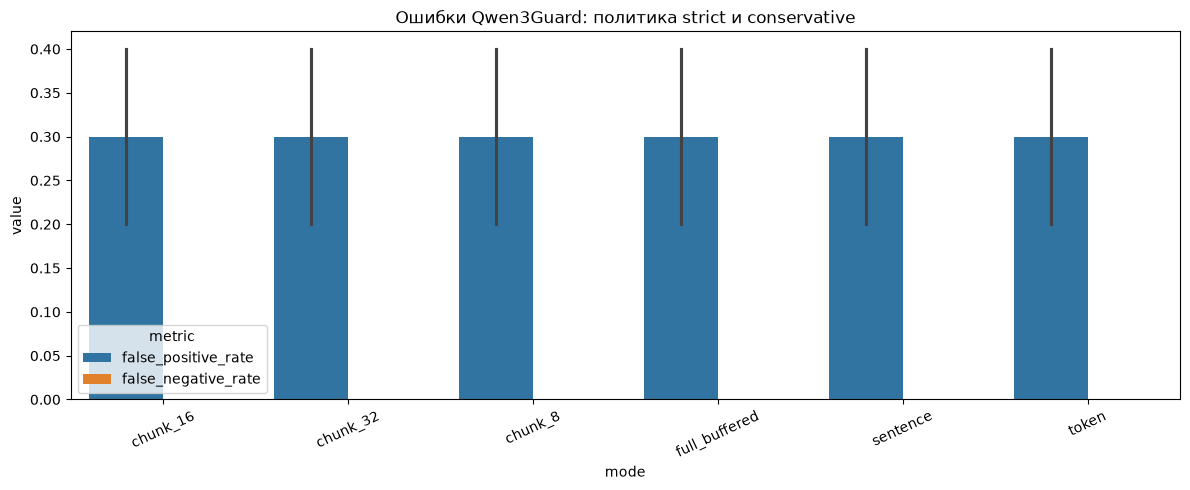

In [8]:
plot_data = metrics.melt(
    id_vars=["mode", "policy"],
    value_vars=["false_positive_rate", "false_negative_rate"],
    var_name="metric",
    value_name="value",
)
plt.figure(figsize=(12, 5))
sns.barplot(data=plot_data, x="mode", y="value", hue="metric")
plt.title(f"Ошибки Qwen3Guard: политика {POLICIES[0]} и {POLICIES[1]}")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## 9. Ошибки без чувствительного текста

In [9]:
if run.errors.empty:
    print("Все выбранные трассы обработаны успешно.")
else:
    display(run.errors[["trace_id", "error_type", "error"]])

Все выбранные трассы обработаны успешно.


## 10. Передача участнику 4

Для полного эксперимента установить `PROFILE = "full"` и `RUN_MODEL = True`, затем выполнить ноутбук на одном зафиксированном устройстве. Профиль обработает все 500 трасс и сформирует 6000 строк. После завершения можно вернуть `RUN_MODEL = False` и повторно открывать результаты без запуска модели.